<a href="https://colab.research.google.com/github/MrSanthosh3/santhosh-codebooster-2026/blob/main/Day2/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqllite3 version: {sqlite3.version}")

All libraries imported successfully
pandas version: 2.2.2
sqllite3 version: 2.6.0


In [ ]:
df= pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn = sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute('SELECT count(*) from students')
count=cursor.fetchone()[0]
print(f"Database 'college.db' create successfully")
print(f"Table 'students' has {count} rows")
cursor.close()
conn.close()

Database 'college.db' create successfully
Table 'students' has 30 rows


In [ ]:
def run_query(query, title):
    conn = sqlite3.connect('college.db')
    df_result = pd.read_sql_query(query, conn)
    conn.close()
    print(title)
    display(df_result)
    return df_result

In [ ]:
query1=""" select student_id, name, department, math_score, attendance_percentage from students limit
            10
            """

result1= run_query(query1, "Query1: First 10 Students (Select+limit)")

Query1: First 10 Students (Select+limit)


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [ ]:
query2="select student_id,name from students limit 5"

result2= run_query(query2, "Query2: First 5 Students")

Query2: First 5 Students


,student_id,name
0,1001,Aarav Sharma
1,1002,Priya Patel
2,1003,Rohit Verma
3,1004,Sneha Reddy
4,1005,Arjun Nair


In [ ]:
query2= "select name, department, math_score from students order by math_score desc limit 5"

result2= run_query(query2, "Query2: Top 5 Students")

Query2: Top 5 Students


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [ ]:
query4="""
select name,math_score,programming_score,attendance_percentage from students where department='Computer Science' limit 10
"""
result=run_query(query4,"Query4: first 10 students from Computer Science")

Query4: first 10 students from Computer Science


,name,math_score,programming_score,attendance_percentage
0,Aarav Sharma,85,91,92
1,Priya Patel,76,79,87
2,Arjun Nair,92,95,90
3,Divya Singh,88,93,96
4,Ananya Das,95,97,98
5,Suresh Rao,83,88,88
6,Ajay Tiwari,71,76,75
7,Swati Kulkarni,90,92,94
8,Nisha Kapoor,79,83,89
9,Tanvi Mehta,93,96,97


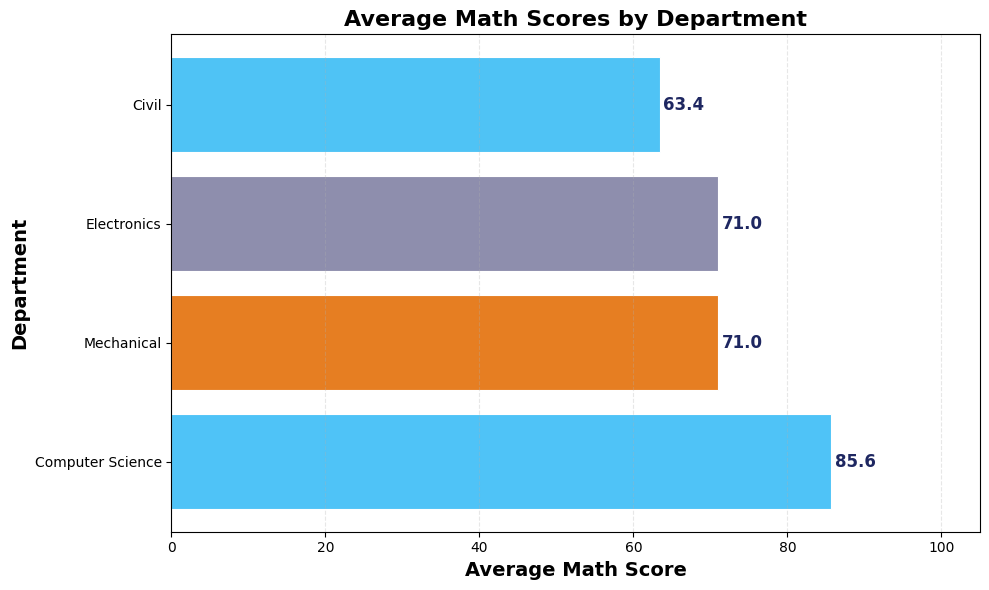

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

df_students = pd.read_csv('student_performance.csv')

df_students.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

chart1_sql = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_colors = ["#4FC3F7", "#E67E22", "#8E8EAD", "#4FC3F5"]

bars = ax.barh(
    chart1_data["department"],   # Y-axis
    chart1_data["avg_math"],     # X-axis
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Math Scores by Department',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Average Math Score',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Department',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlim(0,105)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

conn.close()

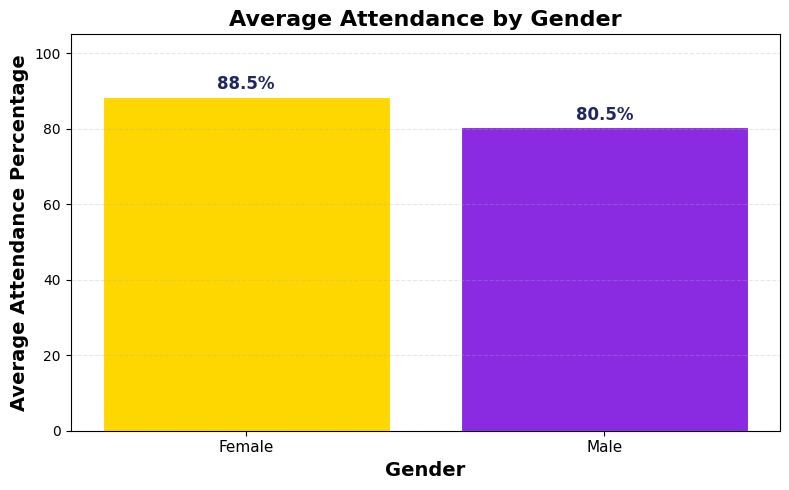

In [5]:
conn = sqlite3.connect('college.db')

chart2_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = ["#FFD700", "#8A2BE2"]

bars = ax.bar(
    chart2_data["gender"],
    chart2_data["avg_attendance"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance by Gender',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Gender',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Average Attendance Percentage',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

conn.close()

In [7]:
import sqlite3
import pandas as pd
from IPython.display import display # Necessary for 'display' in run_query

def run_query(query, title):
    conn = sqlite3.connect('college.db')
    df_result = pd.read_sql_query(query, conn)
    conn.close()
    print(title)
    display(df_result)
    return df_result

query_high_attendance_departments = """
SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
HAVING avg_attendance > 85
ORDER BY avg_attendance DESC;
"""
result = run_query(query_high_attendance_departments, "Departments with Average Attendance > 85")

Departments with Average Attendance > 85


,department,avg_attendance
0,Computer Science,90.69
